#Task 2 (50 points):
In this task, you will pick a dataset (time-series or any other form of
sequential data) and an associated problem that can be solved via sequence models. You must
describe why you need sequence models to solve this problem. Include a link to the dataset
source. Next, you should pick an RNN framework that you would use to solve this problem (This
framework can be in TensorFlow, PyTorch or any other Python Package).

https://www.kaggle.com/datasets/ibrahimshahrukh/coca-cola-ko-stock-prices-19802026

This is the coca cola stock data. The task that I will try to accomplish is the prediction of the daily closing price. I need a sequence model to solve this problem because stock datasets are inherently time series. This means that the order of the data matters. In a normal network, the data is assumed to be i.i.d., and that is just not the case here. Each day's closing price is highly dependent on the prior days. The sequence model will help handle this dependency because they pass information from previous time steps forward. Therefore, using a sequence model will lead to far better outcomes than a simple machine learning model.

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
# get all the historical coca cola stock info
ko = yf.Ticker("KO")
df = ko.history(start="1980-01-01", end="2026-02-28", auto_adjust=True)
df = df.reset_index()

Note: In part 1 and 2, you must perform sufficient data-visualization, pre-processing
and/or feature-engineering if needed. The overall performance visualization of the loss
function should also be provided.

In [ ]:
# save only the relevant columns
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
# convert date into datetime
df['Date'] = pd.to_datetime(df['Date'])

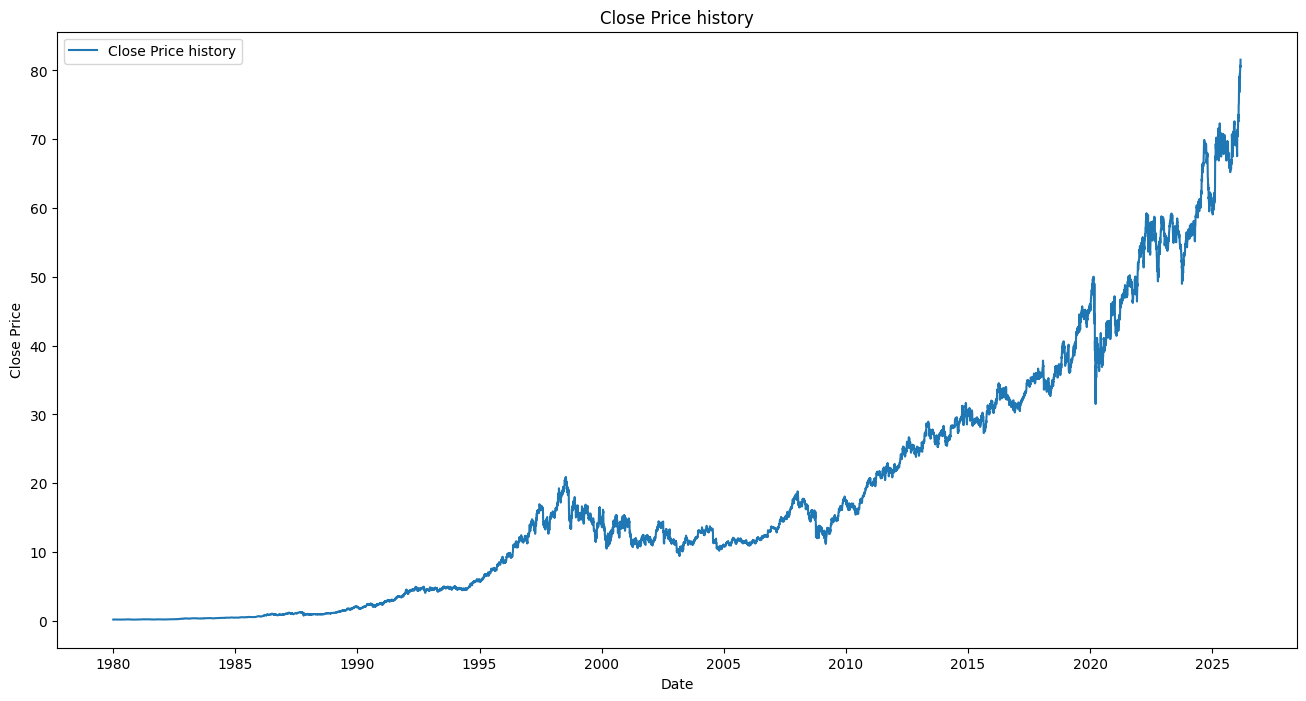

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# graph the close price against each date
plt.figure(figsize=(16,8))
plt.plot(df['Date'], df['Close'], label='Close Price history')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Close Price history')
plt.legend()
plt.show()

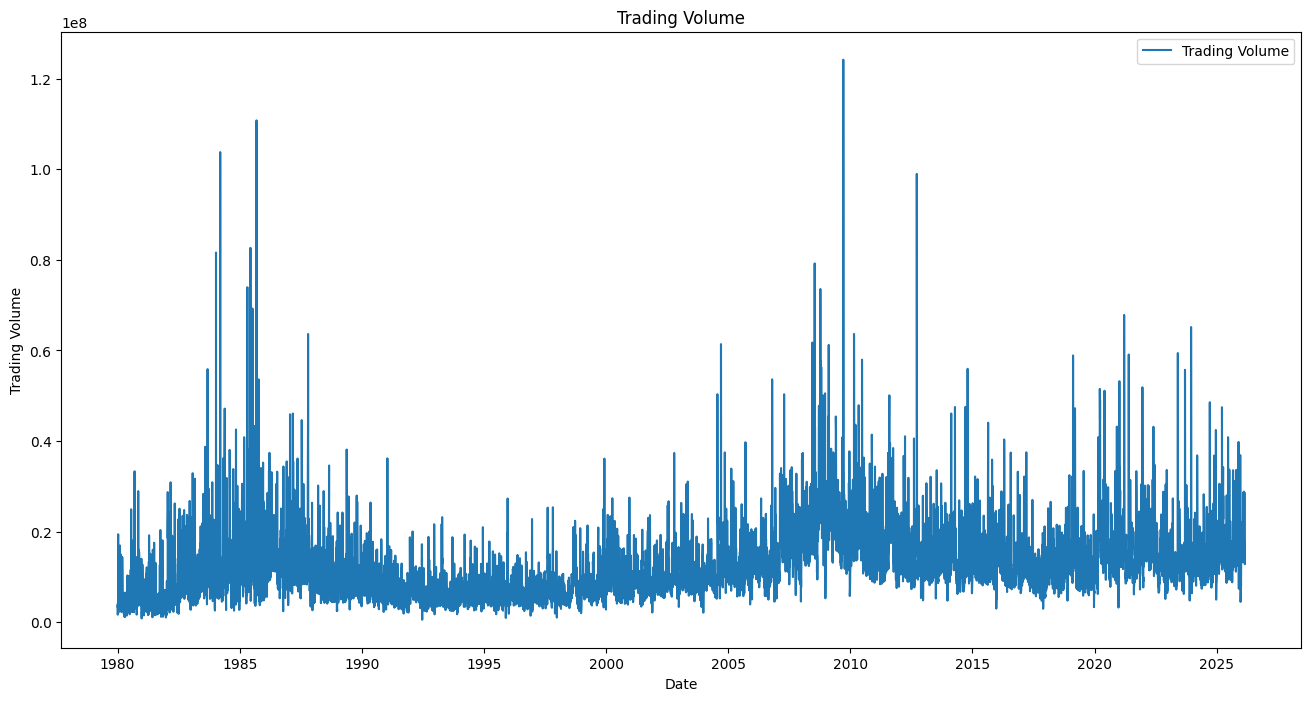

In [ ]:
# graph the trading volume against each date
plt.figure(figsize=(16,8))
plt.plot(df['Date'], df['Volume'], label='Trading Volume')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.title('Trading Volume')
plt.legend()
plt.show()

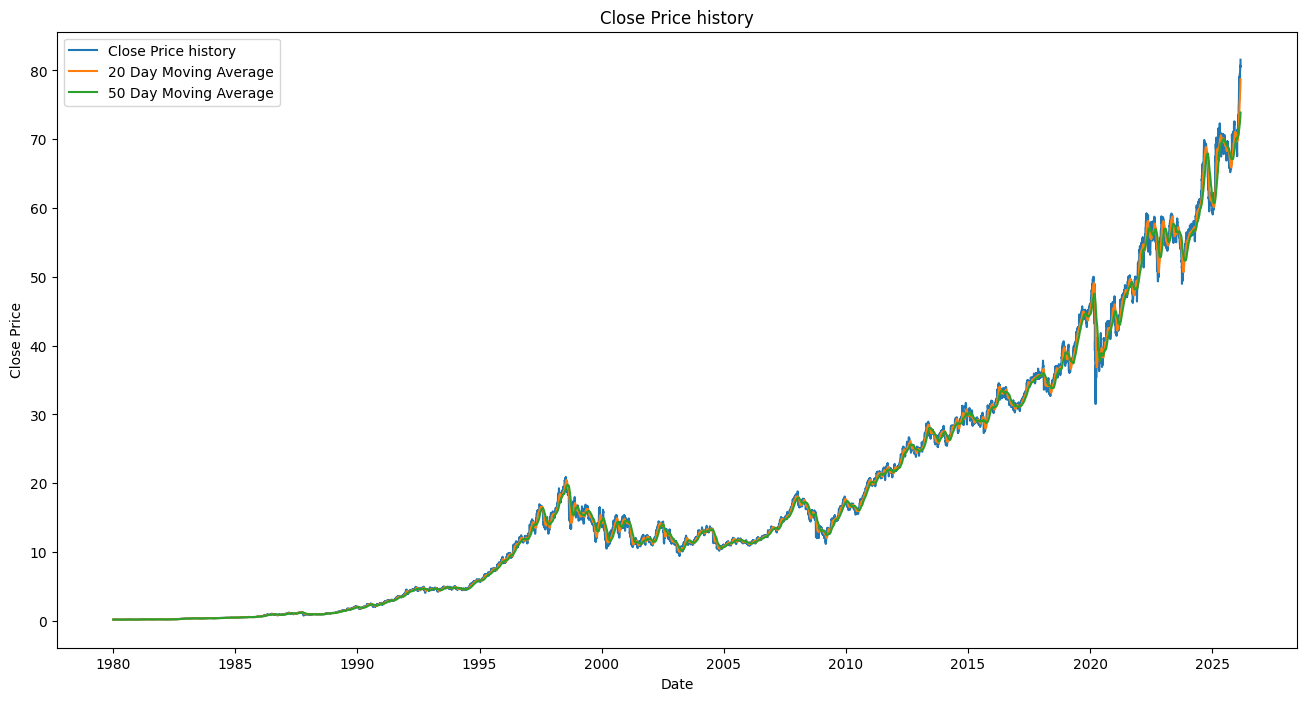

In [ ]:
# plot the 20 and 50 day moving averages
plt.figure(figsize=(16,8))
plt.plot(df['Date'], df['Close'], label='Close Price history')
plt.plot(df['Date'], df['Close'].rolling(window=20, min_periods=1).mean(), label='20 Day Moving Average')
plt.plot(df['Date'], df['Close'].rolling(window=50, min_periods=1).mean(), label='50 Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Close Price history')
plt.legend()
plt.show()

In [ ]:
# remove the date and make a numpy array
features = ['Open', 'High', 'Low', 'Close', 'Volume']
df = df[features].values

In [ ]:
# create the train/val/test boundaries
trainBoundary = int(len(df)*0.7)
valBoundary = int(len(df)*0.9)

trainData = df[:trainBoundary]
valData = df[trainBoundary:valBoundary]
testData = df[valBoundary:]

In [ ]:
# scale the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
trainData = scaler.fit_transform(trainData)
valData = scaler.transform(valData)
testData = scaler.transform(testData)

In [ ]:
# create sequences
def createSequences(data, target, sequenceLength):
    X, y = [], []
    for i in range(sequenceLength, len(data)):
        X.append(data[i-sequenceLength:i])
        y.append(data[i, target])
    return np.array(X), np.array(y)

TARGET = 3
SEQUENCE_LENGTH = 60

trainX, trainY = createSequences(trainData, TARGET, SEQUENCE_LENGTH)
valX, valY = createSequences(valData, TARGET, SEQUENCE_LENGTH)
testX, testY = createSequences(testData, TARGET, SEQUENCE_LENGTH)

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

trainXTensor = torch.tensor(trainX, dtype=torch.float32)
trainYTensor = torch.tensor(trainY, dtype=torch.float32)

valXTensor = torch.tensor(valX, dtype=torch.float32)
valYTensor = torch.tensor(valY, dtype=torch.float32)

testXTensor = torch.tensor(testX, dtype=torch.float32)
testYTensor = torch.tensor(testY, dtype=torch.float32)

trainLoader = DataLoader(TensorDataset(trainXTensor, trainYTensor), batch_size=64, shuffle=True)
valLoader = DataLoader(TensorDataset(valXTensor, valYTensor), batch_size=64, shuffle=False)
testLoader = DataLoader(TensorDataset(testXTensor, testYTensor), batch_size=64, shuffle=False)

##Part 1 (10 points):
Implement your RNN either using an existing framework OR you can
implement your own RNN cell structure. In either case, describe the structure of your
RNN and the activation functions you are using for each time step and in the output
layer. Define a metric you will use to measure the performance of your model (NOTE:
Performance should be measured both for the validation set and the test set).


In [ ]:
import torch.nn as nn

# https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html
# https://medium.com/@noorfatimaafzalbutt/recurrent-neural-networks-rnn-with-pytorch-a-complete-guide-8c40c69032d2
# https://www.geeksforgeeks.org/deep-learning/implementing-recurrent-neural-networks-in-pytorch/
# https://colab.research.google.com/github/dair-ai/pytorch_notebooks/blob/master/RNN_PT.ipynb

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size

        # typical RNN layer
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)

        # output layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # initialize hidden state
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)

        # forward prop
        out, _ = self.rnn(x, h0)

        # keep only the last timestep
        out = self.fc(out[:, -1, :])

        return out

My RNN is taking several days of data (in this case 60) and then predicting the closing price of that final day, therefore, it is a Many-to-One architecture.

For the input layer, we are suing a tensor of the shape batch_size, 60, 5. The 60 can change, but that is how many days prior we are using to predict the current day. The 5 is simply the number of input reaftures.

For the hidden layer, we are using a very plain nn.RNN, these means there are 64 hidden units. For this layer, the activation function is a Tanh. This is a good one as it collapse the values to be between -1 and 1.

The output layer is a fully connected linear layer. This is mapping the final hidden state to to a single contintuous value, which is appropriate because this is a regression task. Hence, we don't want the final output to be a value between 0 and 1 like a classification task would require.

In [ ]:
model = RNN(input_size=5, hidden_size=64, output_size=1)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 20
trainLosses, valLosses = [], []

for epoch in range(epochs):
    model.train()
    batchLosses = []

    for inputs, targets in trainLoader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets.view(-1, 1))
        loss.backward()
        optimizer.step()
        batchLosses.append(loss.item())

    trainLoss = np.mean(batchLosses)

    # validation
    model.eval()
    valLoss = 0
    with torch.no_grad():
        for inputs, targets in valLoader:
            outputs = model(inputs)
            valLoss += criterion(outputs, targets.view(-1, 1)).item()

    valLoss /= len(valLoader)

    trainLosses.append(trainLoss)
    valLosses.append(valLoss)

    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {trainLoss:.6f}, Val Loss: {valLoss:.4f}')

Epoch 1/20, Train Loss: 0.013347, Val Loss: 0.0687
Epoch 2/20, Train Loss: 0.000171, Val Loss: 0.0500
Epoch 3/20, Train Loss: 0.000135, Val Loss: 0.0383
Epoch 4/20, Train Loss: 0.000120, Val Loss: 0.0275
Epoch 5/20, Train Loss: 0.000107, Val Loss: 0.0214
Epoch 6/20, Train Loss: 0.000095, Val Loss: 0.0174
Epoch 7/20, Train Loss: 0.000095, Val Loss: 0.0137
Epoch 8/20, Train Loss: 0.000090, Val Loss: 0.0122
Epoch 9/20, Train Loss: 0.000091, Val Loss: 0.0114
Epoch 10/20, Train Loss: 0.000084, Val Loss: 0.0120
Epoch 11/20, Train Loss: 0.000087, Val Loss: 0.0102
Epoch 12/20, Train Loss: 0.000082, Val Loss: 0.0096
Epoch 13/20, Train Loss: 0.000085, Val Loss: 0.0091
Epoch 14/20, Train Loss: 0.000086, Val Loss: 0.0091
Epoch 15/20, Train Loss: 0.000089, Val Loss: 0.0100
Epoch 16/20, Train Loss: 0.000085, Val Loss: 0.0105
Epoch 17/20, Train Loss: 0.000084, Val Loss: 0.0094
Epoch 18/20, Train Loss: 0.000075, Val Loss: 0.0090
Epoch 19/20, Train Loss: 0.000080, Val Loss: 0.0083
Epoch 20/20, Train Lo

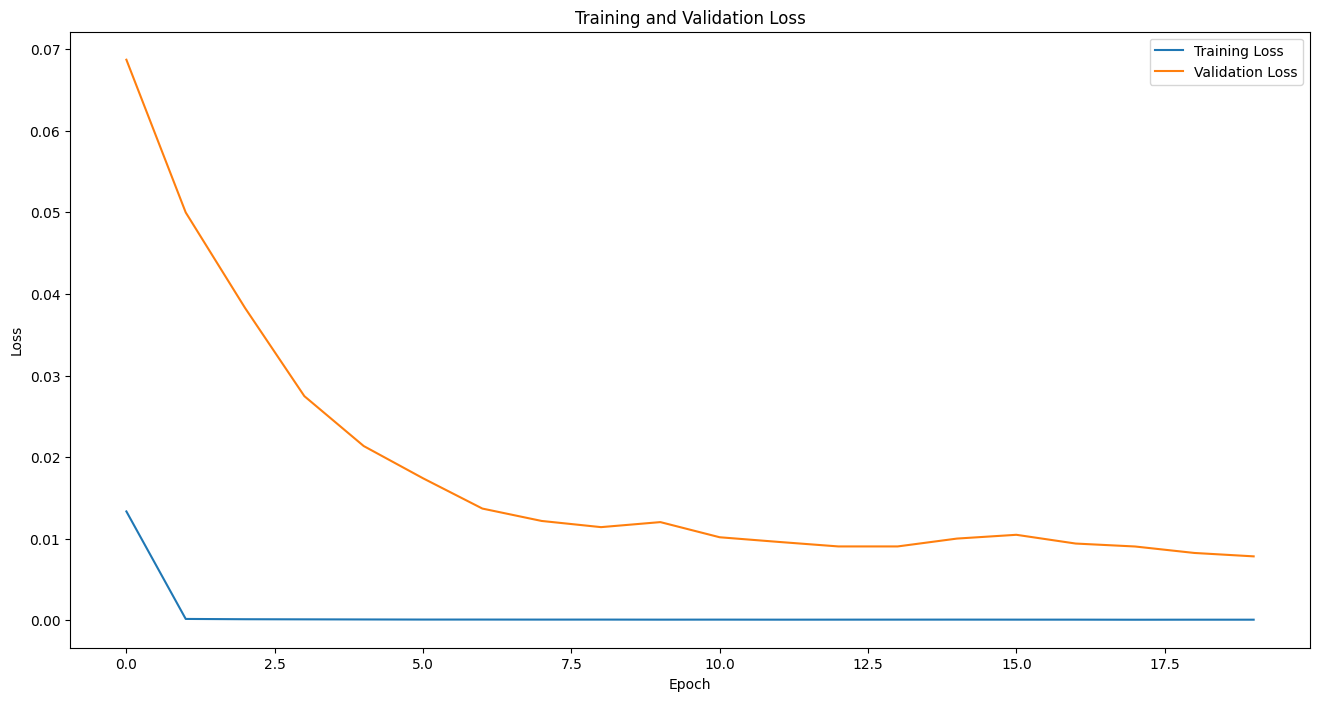

In [ ]:
# make a chart showing the losses
plt.figure(figsize=(16,8))
plt.plot(trainLosses, label='Training Loss')
plt.plot(valLosses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
# model evalutation function
from sklearn.metrics import mean_squared_error
def evaluate(model, dataLoader, criterion):
    model.eval()
    totalLoss = 0
    allPreds, allTargets = [], []

    with torch.no_grad():
        for inputs, targets in dataLoader:
            outputs = model(inputs)
            loss = criterion(outputs, targets.view(-1, 1))
            totalLoss += loss.item()

            allPreds.extend(outputs.cpu().numpy())
            allTargets.extend(targets.cpu().numpy())

    mse = mean_squared_error(allTargets, allPreds)
    rmse = np.sqrt(mse)

    return mse, rmse

In [ ]:
valMSE, valRMSE = evaluate(model, valLoader, criterion)
testMSE, testRMSE = evaluate(model, testLoader, criterion)
RNNMetrics = {'valMSE': valMSE, 'valRMSE': valRMSE, 'testMSE': testMSE, 'testRMSE': testRMSE}
print(f'Validation MSE: {valMSE:.4f}, Validation RMSE: {valRMSE:.4f}')
print(f'Test MSE: {testMSE:.4f}, Test RMSE: {testRMSE:.4f}')

Validation MSE: 0.0073, Validation RMSE: 0.0854
Test MSE: 0.2185, Test RMSE: 0.4674


## Part 2 (30 points):
Update your network from part 1 with first an LSTM and then a GRU
based cell structure (You can treat both as 2 separate implementations). Re-do the
training and performance evaluation. What are the major differences you notice? Why
do you think those differences exist between the 3 implementations (basic RNN, LSTM
and GRU)?

###LSTM

In [ ]:
# https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size

        # typical RNN layer
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)

        # output layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # initialize hidden state
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)

        # forward prop
        out, _ = self.lstm(x, (h0, c0))

        # keep only the last timestep
        out = self.fc(out[:, -1, :])

        return out

In [ ]:
model = LSTM(input_size=5, hidden_size=64, output_size=1)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 20
trainLosses, valLosses = [], []

for epoch in range(epochs):
    model.train()
    batchLosses = []

    for inputs, targets in trainLoader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets.view(-1, 1))
        loss.backward()
        optimizer.step()
        batchLosses.append(loss.item())

    trainLoss = np.mean(batchLosses)

    # validation
    model.eval()
    valLoss = 0
    with torch.no_grad():
        for inputs, targets in valLoader:
            outputs = model(inputs)
            valLoss += criterion(outputs, targets.view(-1, 1)).item()

    valLoss /= len(valLoader)

    trainLosses.append(trainLoss)
    valLosses.append(valLoss)

    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {trainLoss:.6f}, Val Loss: {valLoss:.4f}')

Epoch 1/20, Train Loss: 0.014331, Val Loss: 0.0288
Epoch 2/20, Train Loss: 0.000134, Val Loss: 0.0317
Epoch 3/20, Train Loss: 0.000121, Val Loss: 0.0208
Epoch 4/20, Train Loss: 0.000118, Val Loss: 0.0130
Epoch 5/20, Train Loss: 0.000107, Val Loss: 0.0087
Epoch 6/20, Train Loss: 0.000105, Val Loss: 0.0036
Epoch 7/20, Train Loss: 0.000103, Val Loss: 0.0015
Epoch 8/20, Train Loss: 0.000098, Val Loss: 0.0010
Epoch 9/20, Train Loss: 0.000100, Val Loss: 0.0010
Epoch 10/20, Train Loss: 0.000092, Val Loss: 0.0006
Epoch 11/20, Train Loss: 0.000087, Val Loss: 0.0010
Epoch 12/20, Train Loss: 0.000091, Val Loss: 0.0005
Epoch 13/20, Train Loss: 0.000085, Val Loss: 0.0005
Epoch 14/20, Train Loss: 0.000083, Val Loss: 0.0008
Epoch 15/20, Train Loss: 0.000082, Val Loss: 0.0006
Epoch 16/20, Train Loss: 0.000089, Val Loss: 0.0005
Epoch 17/20, Train Loss: 0.000077, Val Loss: 0.0005
Epoch 18/20, Train Loss: 0.000078, Val Loss: 0.0004
Epoch 19/20, Train Loss: 0.000076, Val Loss: 0.0008
Epoch 20/20, Train Lo

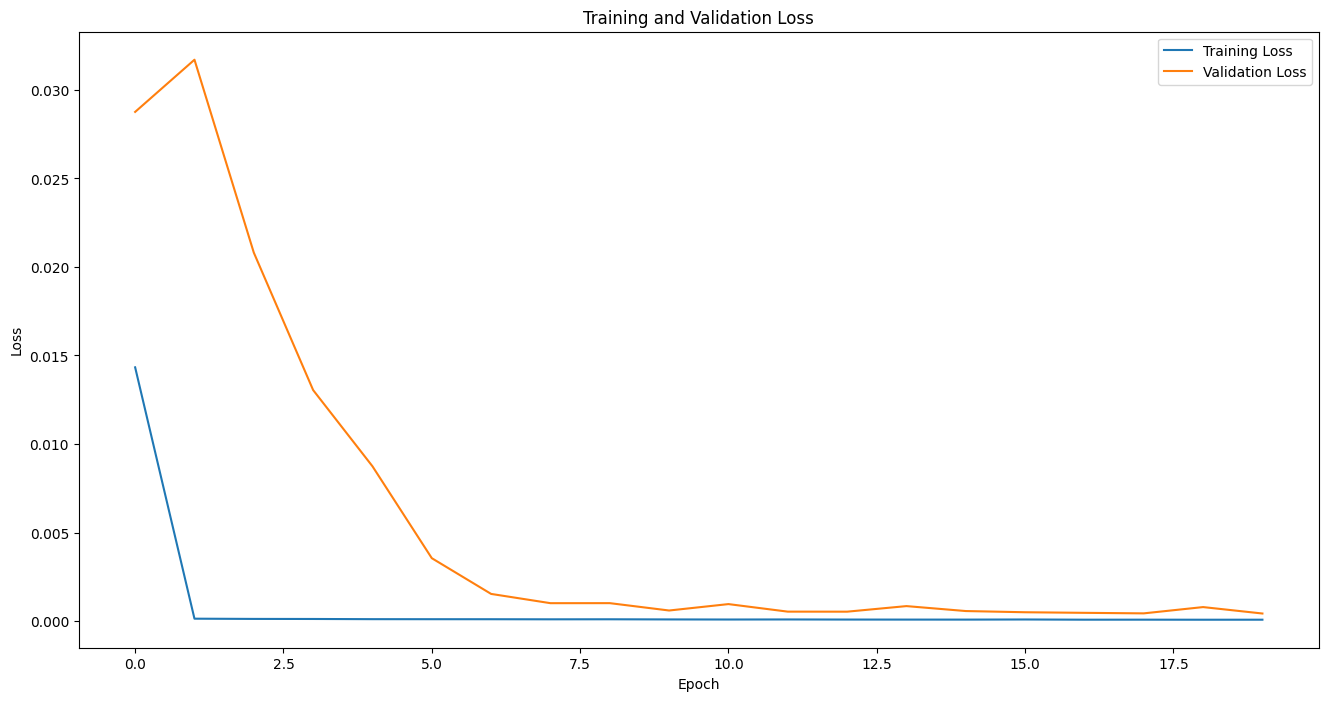

In [ ]:
# make a chart showing the losses
plt.figure(figsize=(16,8))
plt.plot(trainLosses, label='Training Loss')
plt.plot(valLosses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
valMSE, valRMSE = evaluate(model, valLoader, criterion)
testMSE, testRMSE = evaluate(model, testLoader, criterion)
LSTMMetrics = {'valMSE': valMSE, 'valRMSE': valRMSE, 'testMSE': testMSE, 'testRMSE': testRMSE}
print(f'Validation MSE: {valMSE:.4f}, Validation RMSE: {valRMSE:.4f}')
print(f'Test MSE: {testMSE:.4f}, Test RMSE: {testRMSE:.4f}')

Validation MSE: 0.0004, Validation RMSE: 0.0207
Test MSE: 0.0075, Test RMSE: 0.0864


###GRU

In [ ]:
# https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html

class GRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GRU, self).__init__()
        self.hidden_size = hidden_size

        # typical RNN layer
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)

        # output layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # initialize hidden state
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)

        # forward prop
        out, _ = self.gru(x, h0)

        # keep only the last timestep
        out = self.fc(out[:, -1, :])

        return out

In [ ]:
model = GRU(input_size=5, hidden_size=64, output_size=1)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 20
trainLosses, valLosses = [], []

for epoch in range(epochs):
    model.train()
    batchLosses = []

    for inputs, targets in trainLoader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets.view(-1, 1))
        loss.backward()
        optimizer.step()
        batchLosses.append(loss.item())

    trainLoss = np.mean(batchLosses)

    # validation
    model.eval()
    valLoss = 0
    with torch.no_grad():
        for inputs, targets in valLoader:
            outputs = model(inputs)
            valLoss += criterion(outputs, targets.view(-1, 1)).item()

    valLoss /= len(valLoader)

    trainLosses.append(trainLoss)
    valLosses.append(valLoss)

    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {trainLoss:.6f}, Val Loss: {valLoss:.4f}')

Epoch 1/20, Train Loss: 0.014808, Val Loss: 0.0124
Epoch 2/20, Train Loss: 0.000090, Val Loss: 0.0123
Epoch 3/20, Train Loss: 0.000085, Val Loss: 0.0146
Epoch 4/20, Train Loss: 0.000080, Val Loss: 0.0136
Epoch 5/20, Train Loss: 0.000078, Val Loss: 0.0126
Epoch 6/20, Train Loss: 0.000077, Val Loss: 0.0111
Epoch 7/20, Train Loss: 0.000076, Val Loss: 0.0112
Epoch 8/20, Train Loss: 0.000073, Val Loss: 0.0093
Epoch 9/20, Train Loss: 0.000074, Val Loss: 0.0093
Epoch 10/20, Train Loss: 0.000070, Val Loss: 0.0083
Epoch 11/20, Train Loss: 0.000070, Val Loss: 0.0094
Epoch 12/20, Train Loss: 0.000074, Val Loss: 0.0090
Epoch 13/20, Train Loss: 0.000068, Val Loss: 0.0076
Epoch 14/20, Train Loss: 0.000066, Val Loss: 0.0081
Epoch 15/20, Train Loss: 0.000068, Val Loss: 0.0066
Epoch 16/20, Train Loss: 0.000070, Val Loss: 0.0071
Epoch 17/20, Train Loss: 0.000064, Val Loss: 0.0064
Epoch 18/20, Train Loss: 0.000067, Val Loss: 0.0053
Epoch 19/20, Train Loss: 0.000073, Val Loss: 0.0064
Epoch 20/20, Train Lo

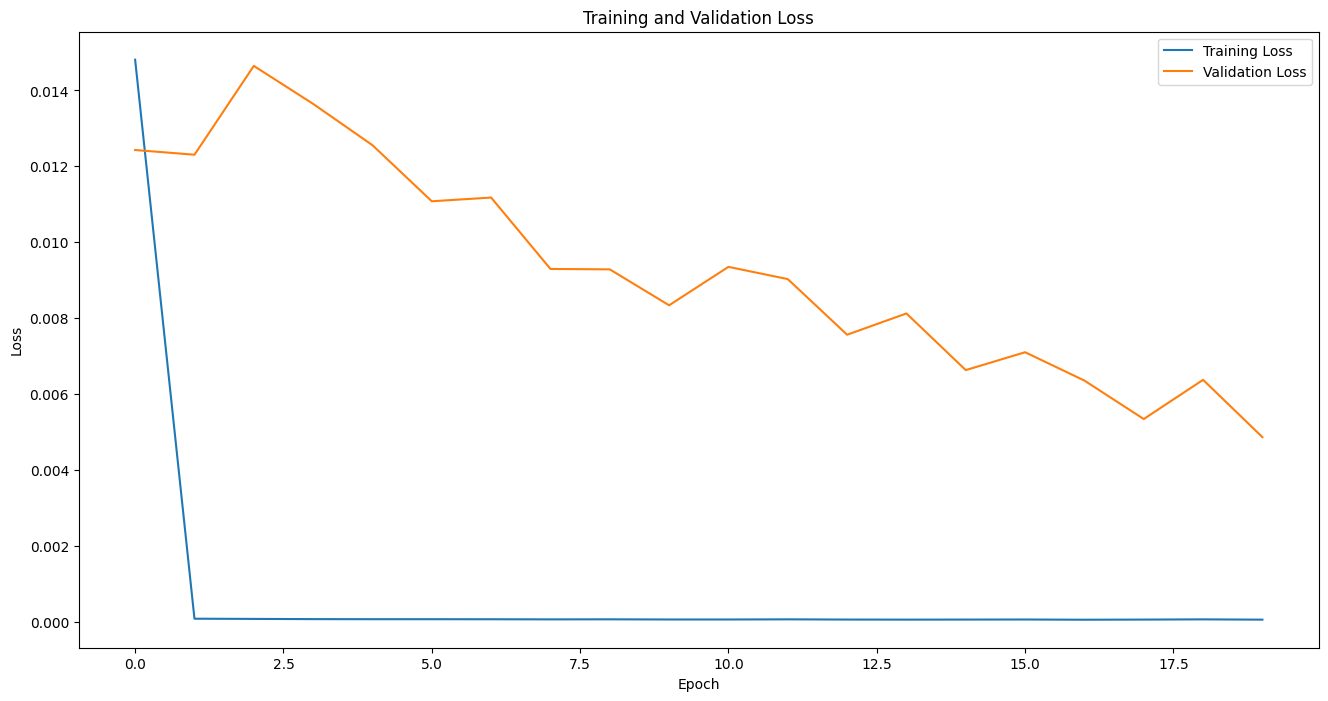

In [ ]:
# make a chart showing the losses
plt.figure(figsize=(16,8))
plt.plot(trainLosses, label='Training Loss')
plt.plot(valLosses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
valMSE, valRMSE = evaluate(model, valLoader, criterion)
testMSE, testRMSE = evaluate(model, testLoader, criterion)
GRUMetrics = {'valMSE': valMSE, 'valRMSE': valRMSE, 'testMSE': testMSE, 'testRMSE': testRMSE}
print(f'Validation MSE: {valMSE:.4f}, Validation RMSE: {valRMSE:.4f}')
print(f'Test MSE: {testMSE:.4f}, Test RMSE: {testRMSE:.4f}')

Validation MSE: 0.0045, Validation RMSE: 0.0671
Test MSE: 0.1545, Test RMSE: 0.3931


In [ ]:
# compare all the values
print('RNN Metrics:')
print(RNNMetrics)
print('LSTM Metrics:')
print(LSTMMetrics)
print('GRU Metrics:')
print(GRUMetrics)

RNN Metrics:
{'valMSE': 0.007294618428255836, 'valRMSE': np.float64(0.08540853838028044), 'testMSE': 0.21845956214303053, 'testRMSE': np.float64(0.4673965790878561)}
LSTM Metrics:
{'valMSE': 0.00042895426205795845, 'valRMSE': np.float64(0.02071121102345197), 'testMSE': 0.0074575106082913414, 'testRMSE': np.float64(0.08635687933390913)}
GRU Metrics:
{'valMSE': 0.0045059632846742225, 'valRMSE': np.float64(0.06712647230917339), 'testMSE': 0.15449801534583985, 'testRMSE': np.float64(0.3930623555440534)}


The first big visual thing we can see is in regards to the validation loss. The basic RNN strugles to reduce the loss on our 60 day windows. The LSTM and GRU have not such issue. This is because the RNN suffers from vanishing gradients. By the time it is processing the data of the final days of the sequence, the first days influence is essential erased. The LSTM and GRU have specific gates to combat this.

In terms of training speed, they are all pretty similar, but the RNN is the fastest and the LSTM sithe slowest. This is rather inconsequential at this scale, but for any larger datasets, this will be of greater notes.

In terms of accuracy, the results are the inverse of the speed. LSTM has by far the best test RMSE, followed by GRU then finally, RNN. This is a testament to how complicated the data is, the more complicated the model is, the better the test RMSE.

##Part 3 (10 points):
Can you use the traditional feed-forward network to solve the same
problem. Why or why not? (Hint: Can time series data be converted to usual features
that can be used as input to a feed-forward network?)

https://www.mathworks.com/matlabcentral/answers/2171924-feedforward-neural-network-with-sliding-windows-approach-to-forecast-output-values

https://en.wikipedia.org/wiki/Recurrent_neural_network

Yes, you can use a ffn to solve the same problem. However, you will have to engineer solutions to problems that you just don't have with the RNN solution.

The big issue is that a ffn would definitionally treat the data as iid. Therefore, there is no concept of time, or that the datapoints are unfolding in any particular order. To make accurate predictions, we would need to overcome this problem.

The solution is to flatten the seiquence. The input would have to have enough neurons to represent each feature on each day. Therefore, for my approach using 5 features and 60 days, you would need 300 neurons. Though doable, this is highly impractical.